WGAN-GP: IL  POTERE DEL GRADIENT PENALITY

WGAN-GP è il miglioramento naturale della WGAN. Se WGAN risolve il grosso problema delle GAN introducendo la distanza Wasserstein, WGAN-GP risolve il principale difetto della prima WGAN: il weight clipping.
L'idea fondamentale:
Invece di limitare brutalmente i pesi del Critic, controlliamo direttamente quanto rapidamente cambia il suo output rispetto all'input.
Questo è il Gradient Penality
Il clipping dei pesi della WGAN può ridurre la capacità del Critic e provocare gradienti che esplodono o svaniscono.

Cosa succede su una funzione cambia troppo velocemente?
L'obbiettivo della WGAN vogliamo che il Critico misuri la distanza tra due mondi. Ma per farlo il critico deve essere onesto, questo si chiama vincolo di Lpschitz
Se le pendenze sono troppo ripide, il scalatore che le deve fare scivolerà. Limitare la pendenza assicura che il critico non dia mai giudizi infinitivamente distanti per immagini che si somigliano molto.

- Una funzione 1-Lipschits garantisce che la differenza tra gli output sia minore o uguale alla distanza tra gli input
- Senza quest limite il critic cercherebbe di assegnare punteggi enormi per le immagini reali e punteggi piccolissimo per immagini fake. Questo causa il collasso del modello.
- Il gradiente unitario assicura che il segnale informativo rimanga costante e ben scalato durante tutto il processo di trainig.
- Il vincolo deve essere rispettato non solo sui dati reali, ma su tutto lo spazio in cui il generatore potrebbe operare.

Ma perchè questa pendenza moderata è così vitale per il successo finale?
Perchè limitare la Pendenza?
Senza un limite alla pendenza, i gradienti potrebbero cresce esponenzialmente, rendendo l'aggiornameto dei pesi instabili (previsione dell'esplosione).
In un duello avversario, è facile che una rete prenda il spravvento sull'altra.
Una pendenza limitata crea una superficie di errore dolce, quasi levigata. Il generatore può sapere che ogni piccolo passo suggerito dal Critico porta ad un miglioramento controllato.
Una funzione con pendenza controllata crea una superficie di errore dolce, ideale per essere navigata dal generatore.
Il rispetto del vincolo è l'unica condizione matematica che permette alla loss del critico di approssimare la distanza di Wasserstein.

Proviamo ad immaginare la forma di questo Critico ideale.
Geometria del Critico.
Immagina il critico come un terreno collinare. Se la pendenza è troppo ripida (gradiente alto), il generatore cade, se è troppo piatta, il generatore non sa dove andare e si perde.
Il vincolo di Lipschitz ci permette di avere colline costanti, dove ogni passo del generatore corrisponde a un miglioramento prevedibile. La pendenza è sempre informativa.
Questo assicura che il critico sia coerente.

Nella prima versione della WGAN si è proposto il weight clipping, questo portava con se degli effetti collaterali rendendo il modello meno intelligente, come cercare di rallentare una macchina mettendo dei blocchi di cemento sulle ruote invece di usare il freno.
Il clipping forza i pesi verso i picchi estremi. Questo danneggia la capacità espressiva, il critico non riesce più ad imparare feature complesse perchè i suoi parametri sono costantemente schiacciati contro un muro.
Il GP (Gradient Penalty) agisce direttamente sulla norma del gradiente aggiungendo un termine alla funzione di loss.
Il GP non limita i pesi, ma penalizza il modello se la pendneza della funzione devia dal valore unitario desiderato.

Vantaggi di GP
I pesi possono crescere quanto vogliono, purchè la pendenza totale rimanga vicino a 1. Questo permette al critico di diventare estremamente sofisticato.
la GP è famosa per la sua stabilità quasi magica, senza che il modello collassi.
Inoltre eliminiamo il limite del clipping che era difficile da tarare manualmente.

Nel 2017 è stata proposta una molla matematica. Invece di un limite rigido, aggiungiamo un termiine alla funzione di perdita. Questo assicura che il gradiente sia sempre informativo. 
Dice alla rete, sei libera di imparare ma se la tua pendenza si allontana da 1 verrai punita. Vogliamo che la funzione sia esattamente 1.

Come calcoliamo questa pendenza?
Non possiamo calcolare il gradiente su ogni possibile punto dello spazio. La soluzione geniale consiste nel campionare lungo le linee che uniscono dati reali e sintetico, e la pendenza è corretta allora il generatore ha una guida sicura per muoversi verso la realtà

- Creiamo immagini interpolate, delle immagini ibride, dei fantasmi che stanno a metà tra il vero ed il falso. Questo pesnado casualmente una coppia formata da un'immagine reale e una generata.
- Calcoliamo l'output del critico su queste immagini e ne estraiamo il gradiente rispetto all input
- La penalità viene applicata al quadrato delle differenze tra la norma di questto gradiente e il valore 1
- Il parametro lambda (solitamente fissato a 10) controlla l'importanza di questo vincolo rispetto alla loss principale.

Ma tecnicameente come faccio a calcolare un gradiente dentro una funzione di loss?

Dettagli tecnici in PyTorch
Usiamo una funzione avanzata di Pythorc: torch.autograd.grad con l'opzione 'create_graph=True per permettere il calcolo delle derivate seconde. E' come se fosse un gradiente nel gradiente.
Attenzione: GP agisce sui singoli campioni, quindi la Batch Normalizzazione standard nel critico va evitata (perchè mescolerebbe le informazioni del batch invalidando il calcolo) o sostituita con la Layer Norm.
Il coefficiente di interpolazione alpha viene campionato da una distribuzione uniforme tra 0 e 1 per ogni coppia del batch.

Il feedback di secondo ordine è ciò che rende la WGAN-GP così speciale, stiamo dando al generatore non solo una direzione ma una mappa di velocità con cui il critico cambia opinione.


Epoca 0 | Loss Critico: -8.0431 | Penalità GP: 0.1198
Epoca 1 | Loss Critico: -8.0958 | Penalità GP: 0.1652
Epoca 2 | Loss Critico: -5.9631 | Penalità GP: 0.0823
Epoca 3 | Loss Critico: -7.4394 | Penalità GP: 0.0979
Epoca 4 | Loss Critico: -4.8159 | Penalità GP: 0.2354
Epoca 5 | Loss Critico: -5.1501 | Penalità GP: 0.1637
Epoca 6 | Loss Critico: -4.9502 | Penalità GP: 0.0260
Epoca 7 | Loss Critico: -4.0103 | Penalità GP: 0.1529
Epoca 8 | Loss Critico: -4.4034 | Penalità GP: 0.0333
Epoca 9 | Loss Critico: -4.7329 | Penalità GP: 0.0307

Training completato. Generazione campioni dimostrativi...


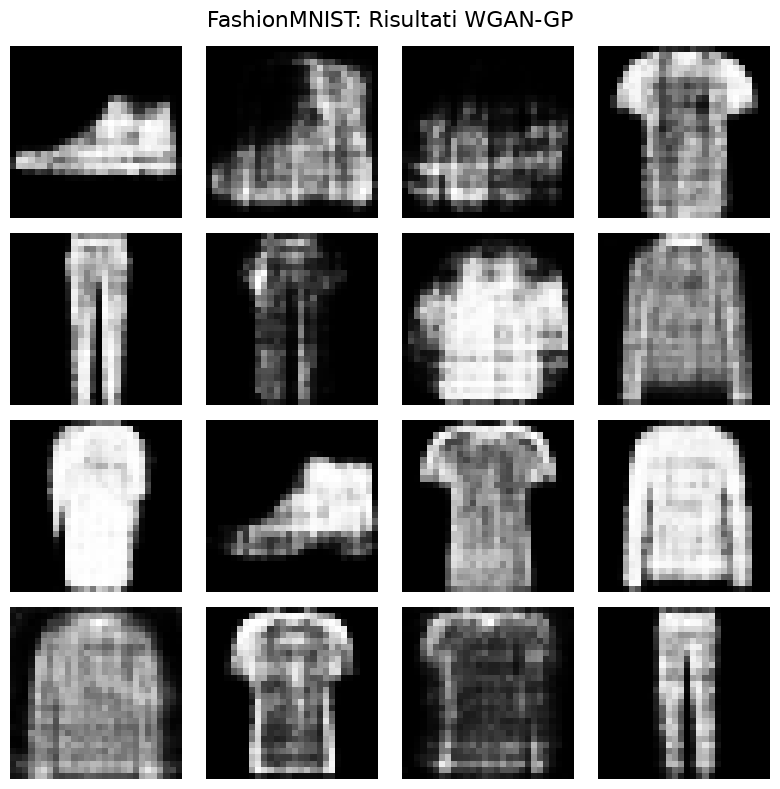

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 1. CONFIGURAZIONE E IPERPARAMETRI ---
# Seleziona la GPU se disponibile per accelerare il calcolo, altrimenti usa la CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensione del vettore latente (rumore casuale in input al generatore)
z_dim = 100

# Learning rate per l'ottimizzatore Adam
lr = 0.0001

# Dimensione del batch di immagini processate ad ogni iterazione
batch_size = 64

# Numero di iterazioni di training del Critico per ogni singola iterazione del Generatore.
# In WGAN, il Critico deve essere addestrato molto meglio del Generatore per fornire gradienti accurati.
n_critic = 5    

# Coefficiente per il Gradient Penalty (lambda).
# Questo valore determina quanto pesantemente penalizzare le violazioni del vincolo matematico di Lipschitz.
lambda_gp = 10  

# --- 2. PREPARAZIONE DEI DATI ---
# Pipeline di trasformazione delle immagini:
# 1. Convertiamo l'immagine in un formato tensore che PyTorch può gestire.
# 2. Normalizziamo i valori dei pixel dall'intervallo [0, 1] all'intervallo [-1, 1].
#    Questo facilita il lavoro del Generatore che usa la funzione di attivazione Tanh (output tra -1 e 1).
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Caricamento del dataset FashionMNIST.
# Il DataLoader gestisce la creazione dei batch e il mescolamento (shuffle) dei dati.
dataloader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- 3. DEFINIZIONE DELLE ARCHITETTURE ---

# Classe Generatore: il suo obiettivo è prendere il rumore casuale e trasformarlo in un'immagine convincente.
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Struttura della rete: una sequenza di strati lineari che espandono le dimensioni
        self.gen = nn.Sequential(
            # Primo strato: dal vettore latente (100) a 256 neuroni
            nn.Linear(z_dim, 256),
            nn.ReLU(True), # Funzione di attivazione ReLU per imparare relazioni non lineari
            
            # Secondo strato: da 256 a 512 neuroni
            nn.Linear(256, 512),
            nn.ReLU(True),
            
            # Terzo strato: da 512 a 784 neuroni (che corrispondono ai 28x28 pixel dell'immagine)
            nn.Linear(512, 784),
            nn.Tanh() # Tanh forza i valori finali tra -1 e 1, corrispondenti alla normalizzazione dei dati reali
        )
    
    # Il metodo forward definisce come i dati passano attraverso la rete.
    # Input z: [batch_size, 100] -> Output: [batch_size, 1, 28, 28]
    def forward(self, z): 
        # L'output lineare viene rimodellato (view) per apparire come un'immagine quadrata
        return self.gen(z).view(-1, 1, 28, 28)

# Classe Critico: nella WGAN si chiama Critico e non Discriminatore.
# Differenza fondamentale: non dice "Vero/Falso" (probabilità 0-1), ma assegna un "Punteggio di Realismo".
# Punteggi più alti = Più probabile che sia reale; Punteggi più bassi = Più probabile che sia falso.
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.critic = nn.Sequential(
            nn.Linear(784, 512),       # Input: immagine appiattita (28x28 = 784)
            nn.LayerNorm(512),         # LayerNorm è preferito a BatchNorm nelle WGAN-GP per stabilità
            nn.LeakyReLU(0.2),         # LeakyReLU evita che i neuroni "muoiano" (zero gradiente) sui valori negativi
            
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            
            nn.Linear(256, 1)          # Output: un singolo numero (score). NESSUNA sigmoide finale.
        )
    
    # Metodo forward: appiattisce l'immagine in ingresso e calcola lo score
    def forward(self, x): 
        return self.critic(x.view(-1, 784))

# --- 4. FUNZIONE GRADIENT PENALTY (Cuore della WGAN-GP) ---
# Questa funzione calcola la penalità necessaria per mantenere stabili i gradienti del Critico.
# Sostituisce il metodo più rozzo di "tagliare" (clip) i pesi usato nelle WGAN originali.
def compute_gradient_penalty(critic, real_samples, fake_samples):
    # 1. Prendiamo un numero casuale (alpha) tra 0 e 1 per ogni immagine nel batch
    alpha = torch.rand((real_samples.size(0), 1, 1, 1), device=device)
    
    # 2. Creiamo immagini "interpolate" che sono una via di mezzo tra quelle reali e quelle generate.
    #    Matematicamente: inter = alpha * reale + (1-alpha) * fake
    interpolated = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    
    # 3. Chiediamo al Critico di valutare queste immagini ibride
    d_interpolated = critic(interpolated)
    
    # 4. Calcoliamo il gradiente dell'output del critico rispetto alle immagini interpolate.
    #    Vogliamo sapere: "Quanto cambia il giudizio del critico se cambio leggermente l'immagine?"
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,   # Necessario per poter derivare nuovamente durante la backprop
        retain_graph=True
    )[0]
    
    # 5. Calcoliamo la lunghezza (norma) di questo vettore gradiente
    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)
    
    # 6. La regola matematica (Lipschitz) dice che questa norma dovrebbe essere al massimo 1.
    #    WGAN-GP penalizza la distanza di questa norma da 1. Cioè, vogliamo che la pendenza sia esattamente 1.
    penalty = torch.mean((gradient_norm - 1) ** 2)
    return penalty

# Inizializzazione dei modelli e spostamento sul dispositivo (CPU o GPU)
gen = Generator().to(device)
critic = Critic().to(device)

# Definizione degli ottimizzatori. Adam funziona bene con WGAN-GP.
# I parametri betas=(0.5, 0.9) sono standard per la stabilità delle GAN.
opt_G = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.9))
opt_C = optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))

# --- 5. CICLO DI TRAINING ---

for epoch in range(10): # Eseguiamo per 10 epoche
    for i, (real_imgs, _) in enumerate(dataloader):
        # Spostiamo le immagini reali sul device corretto
        real_imgs = real_imgs.to(device)
        curr_batch_size = real_imgs.size(0)

        # --- FASE A: ADDESTRAMENTO DEL CRITICO ---
        # Il Critico viene aggiornato più volte (n_critic) per ogni passo del Generatore.
        # Questo assicura che il Generatore riceva un feedback di alta qualità.
        for _ in range(n_critic):
            opt_C.zero_grad() # Pulizia dei gradienti precedenti
            
            # Generiamo un batch di immagini false
            z = torch.randn(curr_batch_size, z_dim, device=device)
            fake_imgs = gen(z).detach() # .detach() è cruciale: non vogliamo aggiornare il generatore ora
            
            # Calcolo della Loss WGAN: differenza tra i punteggi medi delle immagini reali e false.
            # Il Critico vuole dare voti alti alle reali e bassi alle false.
            # Quindi vuole MASSIMIZZARE (D(reale) - D(fake)).
            # In PyTorch minimizziamo, quindi usiamo il segno meno: -(D(reale) - D(fake))
            loss_W = -(torch.mean(critic(real_imgs)) - torch.mean(critic(fake_imgs)))
            
            # Calcolo della penalità del gradiente sulle immagini interpolate
            gp = compute_gradient_penalty(critic, real_imgs, fake_imgs)
            
            # La Loss totale del Critico è la Loss WGAN più la penalità pesata
            loss_C = loss_W + lambda_gp * gp
            
            # Calcolo dei gradienti e aggiornamento dei pesi del Critico
            loss_C.backward()
            opt_C.step()

        # --- FASE B: ADDESTRAMENTO DEL GENERATORE ---
        opt_G.zero_grad()
        
        # Generiamo nuove immagini false (questa volta senza detach, perché vogliamo addestrare il generatore)
        z = torch.randn(curr_batch_size, z_dim, device=device)
        fake_imgs = gen(z)
        
        # Loss del Generatore: deve ingannare il Critico.
        # Vuole che il Critico dia un punteggio ALTO alle immagini fake.
        # Quindi vuole MASSIMIZZARE D(fake), che equivale a MINIMIZZARE -D(fake)
        loss_G = -torch.mean(critic(fake_imgs))
        
        # Calcolo dei gradienti e aggiornamento dei pesi del Generatore
        loss_G.backward()
        opt_G.step()

    # Feedback all'utente alla fine di ogni epoca
    print(f"Epoca {epoch} | Loss Critico: {loss_C.item():.4f} | Penalità GP: {gp.item():.4f}")

# --- 6. VISUALIZZAZIONE DEI RISULTATI ---
import matplotlib.pyplot as plt

print("\nTraining completato. Generazione campioni dimostrativi...")

# Mettiamo il generatore in modalità 'eval' (best practice, anche se qui non abbiamo dropout)
gen.eval()

with torch.no_grad():
    # Usiamo un seed fisso di rumore per vedere cosa produce il generatore
    fixed_noise = torch.randn(16, z_dim, device=device)
    
    # Generiamo le immagini e le portiamo sulla CPU per visualizzarle
    fake_samples = gen(fixed_noise).cpu()
    
    # Creazione della griglia di immagini
    plt.figure(figsize=(8, 8))
    plt.suptitle("FashionMNIST: Risultati WGAN-GP", fontsize=16)
    
    for i in range(16):
        plt.subplot(4, 4, i+1)
        
        # Denormalizzazione: dobbiamo riportare i valori da [-1, 1] a [0, 1] per poterli visualizzare correttamente
        img = (fake_samples[i].squeeze() + 1) / 2
        
        plt.imshow(img, cmap='gray')
        plt.axis('off') # Rimuovo i numeri degli assi per pulizia
    
    plt.tight_layout()
    plt.show()